In [226]:
import matplotlib.pyplot as plt
import numpy as np
from random import random
import scipy.stats as stats

# Problem 2

In [170]:
inverse_cdf_x = lambda eta: 2 * eta**(1/3)


def sample_x(n):
    """ samples the pdf of x with n samples """
    total = 0

    for count in range(0, n):
        eta = random()
        sampled_x = inverse_cdf_x(eta)
        total += sampled_x

    mean = total / n
    return mean


# sampling
mean_analytic = 3 / 2  # calculation provided in hw pdf submission

mean_1k = sample_x(1_000)
mean_1k_diff = mean_1k - mean_analytic

mean_50k = sample_x(50_000)
mean_50k_diff = mean_50k - mean_analytic

print(f"Analytical Mean:         {mean_analytic}")
print(f"Mean with 1k samples:    {mean_1k:.6f}")
print(f"    abs diff from mean:  {abs(mean_1k_diff):.6e}")
print(f"Mean with 50k samples:   {mean_50k:.6f}")
print(f"    abs diff from mean:  {abs(mean_50k_diff):.6e}")

Analytical Mean:         1.5
Mean with 1k samples:    1.504458
    abs diff from mean:  4.457517e-03
Mean with 50k samples:   1.502462
    abs diff from mean:  2.462294e-03


# Problem 3

## 3.1 - probability mixing method

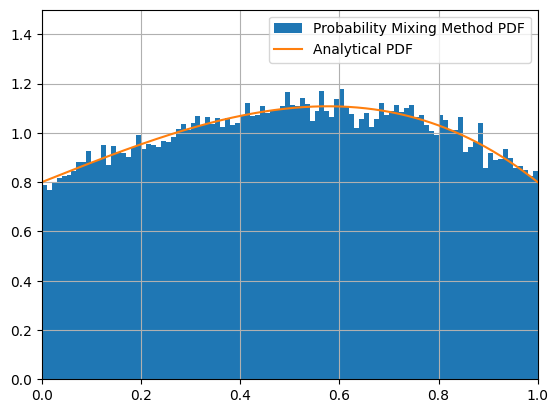

In [223]:
n_samples = 100_000

# pdf variables
alpha1 = 5/3
alpha2 = 5/2

pdf1_x = lambda x: 4 / 3 * (1 - x**3)
inverse_cdf2_x = lambda eta: eta**(1/2)
full_pdf_x = lambda x: 4/5 * (1 + x - x**3)

# variables for sampling p1
a = 0
b = 1
p_max = 4/3


# sampling functions
def sample_p1(a=a, b=b, p_max=p_max):
    while True:
        eta1, eta2 = random(), random()

        sampled_x = a + eta1 * (b - a)
        sampled_pdf1_x = pdf1_x(sampled_x)

        if eta2 * p_max <= sampled_pdf1_x:
            return sampled_x


def sample_p2():
    eta1 = random()

    sampled_x = inverse_cdf2_x(eta1)
    return sampled_x


def sample_p():
    eta1 = random()

    sampled_x = sample_p1() if (eta1 <= 1 / alpha1) else sample_p2()
    return sampled_x


def plot_histogram(n_bins):
    x_samples = np.array([sample_p() for _ in range(n_samples)])
    plt.hist(x_samples, n_bins, density=True, label="Probability Mixing Method PDF")


# plotting
plot_histogram(100)

xs = np.linspace(0, 1, 10000)
ps = full_pdf_x(xs)

plt.plot(xs, ps, label="Analytical PDF")
plt.xlim(0, 1)
plt.ylim(0, 1.5)

plt.grid(which="both")

plt.legend()
plt.savefig("q3p1.png", dpi=600)
plt.show()

## 3.2 - analytical FFMC

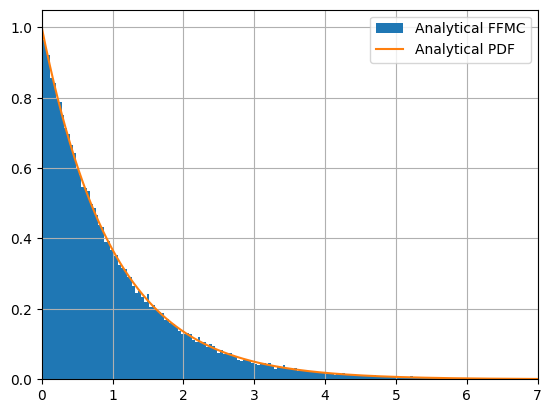

In [222]:
n_samples = 100_000

inverse_cdf_x = lambda eta: -np.log(1 - eta)
pdf_x = lambda x: np.exp(-x)

def sample_p():
    while True:
        try:
            eta = random()
            sampled_x = inverse_cdf_x(eta)
            return sampled_x
        except:
            continue


def plot_histogram(n_bins):
    x_samples = np.array([sample_p() for _ in range(n_samples)])
    plt.hist(x_samples, n_bins, density=True, label="Analytical FFMC", range=(0,100))


# plotting
plot_histogram(2500)

xs = np.linspace(0, 10, 10000)
ps = pdf_x(xs)

plt.plot(xs, ps, label="Analytical PDF")
plt.xlim(0, 7)

plt.grid(which="both")

plt.legend()
plt.savefig("q3p2.png", dpi=600)
plt.show()

# Problem 5

Write codes to sample a standard normal distribution based on numerical inversion and rejection
technique. Plot a histogram of the sampled x values for 100, 000 samples. Compare this to the true
PDF. (You can generate samples for η using the standard uniform distribution.)

In [255]:
n_samples = 100_000

pdf_x = lambda x: 1 / (2 * np.pi)**(1/2)

# numerical inversion
x_start = -5
x_end   = 5

n_bins = 4

## obtaining probabilities
epsilon = 1e-5
quantiles = np.linspace(0, 1, n_bins + 1)
quantiles[0] = epsilon
quantiles[-1] = 1 - epsilon

bin_boundaries = stats.norm.ppf(quantiles)


def sample_p_numerical_inversion(n_bins=n_bins):
    eta1, eta2 = random(), random()

    interval_index = int(n_bins * eta_1) + 1
    sampled_x = bin_boundaries[interval_index - 1] + eta2 * (bin_boundaries[interval_index] - bin_boundaries[interval_index - 1])
    return


# rejection sampling
pmax = 1 / (2 * np.pi)**(1/2)
a = -6
b = 6


def sample_p_rejection(pmax=pmax, a=a, b=b):
    while True:
        eta1, eta2 = random(), random()
    
        sampled_x = a + eta1 * (b - a)
        sampled_pdf_x = pdf_x(sampled_x)
    
        if eta2 * p_max <= sampled_pdf_x:
            return sampled_x

In [229]:
eps = 1e-5
N_bins = 5

quants = np.linspace(eps, 1-eps, N_bins+1)
quants

stats.norm.ppf()

array([1.00000e-05, 2.00006e-01, 4.00002e-01, 5.99998e-01, 7.99994e-01,
       9.99990e-01])